In [1]:
import sys
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

from src.portfolio.positions import Portfolio
from src.stress.historical import stress_window
from src.stress.hypothetical import apply_vol_scaling
from src.stress.scenarios import increase_correlation
from src.stress.reporting import stress_loss_distribution
from src.stress.run_stress import (
    stress_var,
    run_stress)
from src.utils.config import load_config
from src.data.loaders import load_prices
from src.data.features import compute_log_returns
from src.portfolio.pnl import compute_portfolio_pnl
from src.risk.var_parametric import parametric_var_from_cov
from src.risk.var_montecarlo import mc_var_from_cov
from src.risk.covariance import ewma_covariance

## Load Data

In [2]:
# Load data and compute returns
portfolio_cfg = load_config(Path("../configs/portfolio.yaml"))
risk_cfg = load_config(Path("../configs/risk.yaml"))
stress_cfg = load_config(Path("../configs/stress.yaml"))

tickers = portfolio_cfg["portfolio"]["tickers"]
notional = portfolio_cfg["portfolio"]["notional"]

prices = load_prices(
    tickers,
    start=risk_cfg["risk"]["start_date"],
    end=risk_cfg["risk"]["end_date"]
)

returns = compute_log_returns(prices)

portfolio = Portfolio.from_equal_weight(
    tickers=tickers,
    notional=notional
)

Cached prices available
Cached data covers request. Loading from cache.


## Historical Crisis (Covid period)

### Compute stress period losses and VaR
This may take a few seconds...

In [3]:
# Compute stress period losses and VaR
stress_start = stress_cfg["stress"]["scenarios"]["covid_crash"]["start"]
stress_end = stress_cfg["stress"]["scenarios"]["covid_crash"]["end"]
covid_returns = stress_window(
    returns,
    stress_start,
    stress_end
)

covid_losses = stress_loss_distribution(
    covid_returns,
    portfolio.weights,
    portfolio.notional
)

crisis_models = {
    "Parametric EWMA": "parametric_ewma",
    "Monte Carlo EWMA": "mc_ewma",
    "FHS": "fhs"
}

crisis_results = {}

for name, model in crisis_models.items():

    crisis_results[name] = run_stress(
        returns,
        portfolio,
        start=stress_start,
        end=stress_end,
        model=model,
        alpha=stress_cfg["stress"]["alpha"], # = 0.99
        seed=42
    )

loss_metrics = pd.DataFrame({
    "Worst Loss": covid_losses.max(),
    "95% Quantile": covid_losses.quantile(0.95),
    "99% Quantile": covid_losses.quantile(0.99),
    "Mean Loss": covid_losses.mean()
}, index=[0])
print("\nCOVID Crisis Loss Metrics")
print("---------------------------")
print(loss_metrics.head())
# Optional: Display VaR results for one of the models (e.g., Parametric EWMA)
# name = "Parametric EWMA"
# covid_var = crisis_results[name]
# print(f"\nCOVID Crisis VaR {name}")
# print("----------------")
# print(covid_var.head())


COVID Crisis Loss Metrics
---------------------------
     Worst Loss   95% Quantile  99% Quantile     Mean Loss
0  1.335697e+06  777798.965998  1.202261e+06  35164.476908


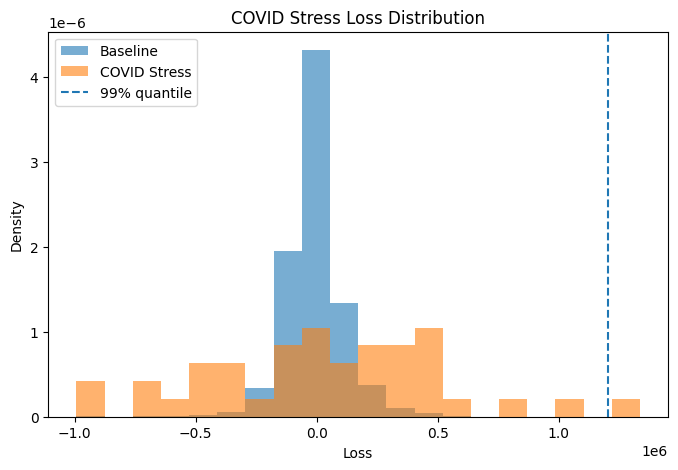

In [4]:
# Loss distribution plot
covid_tail = covid_losses.quantile(0.99)
baseline_losses = stress_loss_distribution(
    returns,
    portfolio.weights,
    portfolio.notional
)
plt.figure(figsize=(8,5))
plt.hist(baseline_losses, bins=20, alpha=0.6, label="Baseline",density=True)
plt.hist(covid_losses, bins=20, alpha=0.6, label="COVID Stress",density=True)
plt.axvline(covid_tail, linestyle="--",label="99% quantile")
plt.title("COVID Stress Loss Distribution")
plt.xlabel("Loss")
plt.ylabel("Density")
plt.legend()

# Save Plot
fig_dir = Path("../reports/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "covid_stress_loss_distribution.png")

plt.show()

### Summary Statistics and Loss vs VaR Plots

              Model    Worst Loss       Avg VaR  Stress Loss / Normal VaR  \
0   Parametric EWMA  1.335697e+06  8.615310e+05                  1.550376   
1  Monte Carlo EWMA  1.335697e+06  8.565237e+05                  1.559440   
2               FHS  1.335697e+06  1.121432e+06                  1.191063   

   Observations  Exceptions  Exception Rate  
0            41           5        0.121951  
1            41           6        0.146341  
2            41           2        0.048780  


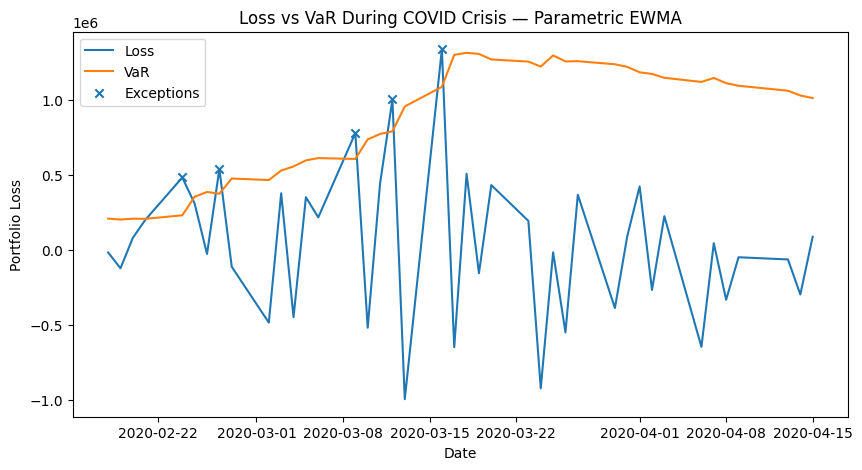

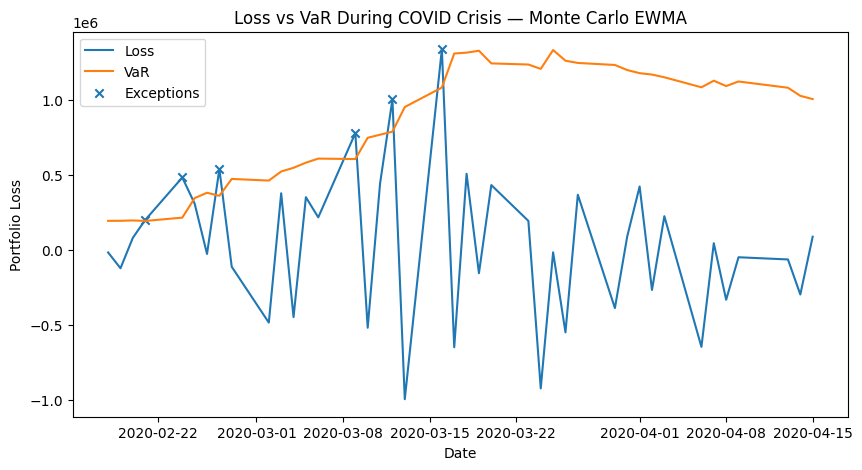

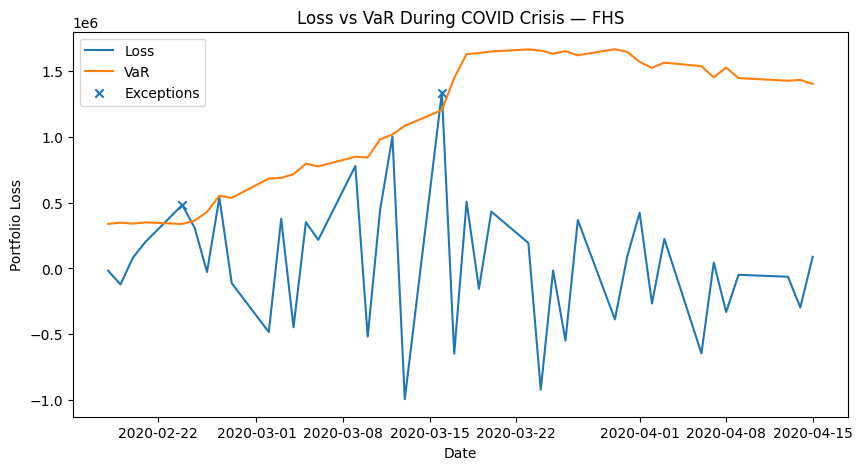

In [5]:
# Exception Statistics
summary = []

for name, df in crisis_results.items():

    worst_loss = df["Loss"].max()
    avg_var = df["VaR"].mean()
    exceptions = df["Exception"].sum()
    n_obs = len(df)

    summary.append({
        "Model": name,
        "Worst Loss": worst_loss,
        "Avg VaR": avg_var,
        "Stress Loss / Normal VaR": worst_loss / avg_var,
        "Observations": n_obs,
        "Exceptions": exceptions,
        "Exception Rate": exceptions / n_obs
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

# For saving plots
fig_dir = Path("../reports/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Plot Loss vs VaR for each model
for name, df in crisis_results.items():

    exceptions = df[df["Exception"]]

    plt.figure(figsize=(10,5))

    plt.plot(df.index, df["Loss"], label="Loss")
    plt.plot(df.index, df["VaR"], label="VaR")

    plt.scatter(
        exceptions.index,
        exceptions["Loss"],
        marker="x",
        label="Exceptions"
    )

    plt.title(f"Loss vs VaR During COVID Crisis — {name}")
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Portfolio Loss")
    # Save Plot
    filename = name.lower().replace(" ", "_")

    plt.savefig(fig_dir / f"covid_loss_vs_var_{filename}.png", dpi=300)
    
    plt.show()

### Crisis Shock Summary
All models experienced substantially more exceptions than expected, indicating that the extreme market conditions were not well captured by the VaR models calibrated on historical data.

Among the models:

* FHS produced the highest average VaR, resulting in the lowest exception rate (0.049), although still substantially higher than expected for a 99% VaR.
* Parametric EWMA and Monte Carlo EWMA behaved similarly (with rates 0.122 and 0.146, respectively), reflecting their shared dependence on the same volatility estimate.
* The Monte Carlo approach did not materially improve performance over the parametric model because both assume the same covariance structure.

The largest observed loss to VaR ratios were 1.55, 1.56, and 1.20 for the parametric EWMA, Monte Carlo EWMA, and FHS, respectively. showing that the models moderately underestimates tail severity in extreme market conditions.

Overall, Filtered Historical Simulation appears more robust in crisis conditions, as it better captures heavy-tailed return behavior.

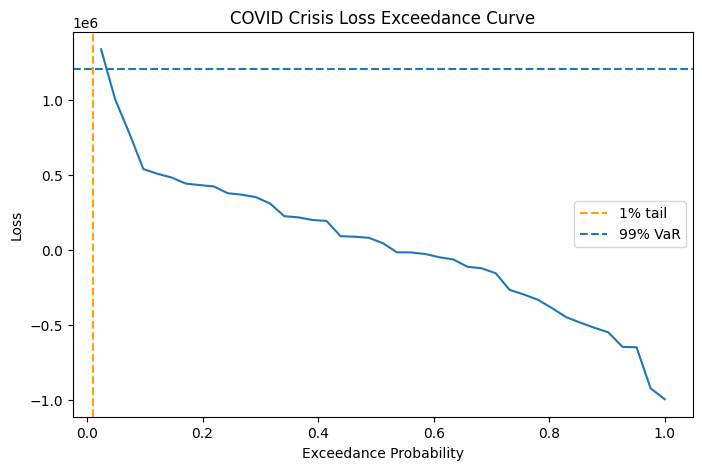

In [7]:
# Loss exceedance curve (tail plot)

sorted_losses = covid_losses.sort_values(ascending=False).reset_index(drop=True)

exceedance_prob = (sorted_losses.index + 1) / len(sorted_losses)

plt.figure(figsize=(8,5))

plt.plot(exceedance_prob, sorted_losses)

plt.axvline(0.01, linestyle="--", label="1% tail", color="orange")
plt.axhline(covid_tail, linestyle="--", label="99% VaR")

plt.xlabel("Exceedance Probability")
plt.ylabel("Loss")
plt.title("COVID Crisis Loss Exceedance Curve")

plt.legend()

# Save Plot
plt.savefig(fig_dir / "covid_loss_exceedance_curve.png", dpi=300)
plt.show()

The loss exceedance curve shows a steep increase in losses among the worst observations, indicating that extreme losses escalate rapidly beyond the 99% VaR threshold. However, the small sample size of the COVID stress window limits the precision of tail probability estimates.

## Hypothetical Market Shock

### Volatility Shock

In [8]:
shock_cfg = stress_cfg["stress"]["scenarios"]["hypothetical_market_shock"]

vol_scale = shock_cfg["vol_scale"]
alpha = stress_cfg["stress"]["alpha"]

stressed_returns = apply_vol_scaling(returns, vol_scale)
stressed_losses = stress_loss_distribution(
    stressed_returns,
    portfolio.weights,
    portfolio.notional
)

Compute Baseline Loss Distribution and Stressed VaR

In [9]:
stressed_tail = stressed_losses.quantile(alpha)

baseline_losses = stress_loss_distribution(
    returns,
    portfolio.weights,
    portfolio.notional
)

baseline_tail = baseline_losses.quantile(alpha)

Compare Distribution Metrics

Volatility Shock Summary
---------------------------------
Baseline worst loss: 1335696.88
Stressed worst loss: 2671393.76
Baseline Historical VaR (99%): 366612.70
Stressed Historical VaR (99%): 733225.39
VaR uplift: 2.00x
Worst-loss uplift: 2.00x


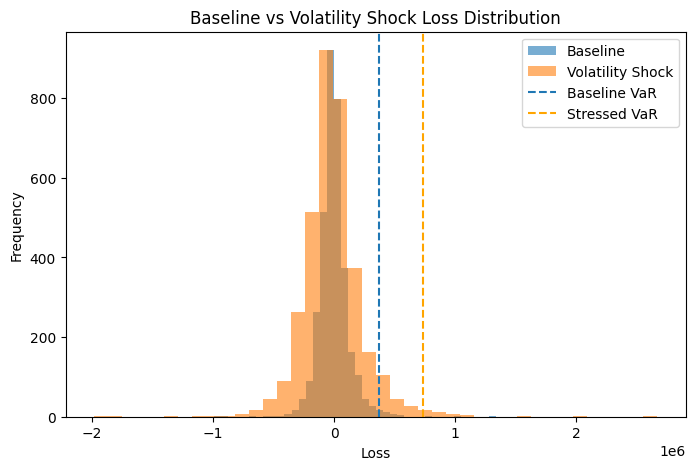

In [10]:
print("Volatility Shock Summary")
print("---------------------------------")
print(f"Baseline worst loss: {baseline_losses.max():.2f}")
print(f"Stressed worst loss: {stressed_losses.max():.2f}")
print(f"Baseline Historical VaR ({alpha:.0%}): {baseline_tail:.2f}")
print(f"Stressed Historical VaR ({alpha:.0%}): {stressed_tail:.2f}")
print(f"VaR uplift: {stressed_tail / baseline_tail:.2f}x")
print(f"Worst-loss uplift: {stressed_losses.max() / baseline_losses.max():.2f}x")

# Plot Baseline vs Stressed Loss Distributions
plt.figure(figsize=(8, 5))
plt.hist(baseline_losses, bins=40, alpha=0.6, label="Baseline")
plt.hist(stressed_losses, bins=40, alpha=0.6, label="Volatility Shock")
plt.axvline(baseline_tail, linestyle="--", label="Baseline VaR") # Historical VaR for illustration
plt.axvline(stressed_tail, linestyle="--", label="Stressed VaR", color="orange")
plt.title("Baseline vs Volatility Shock Loss Distribution")
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.legend()
# Save Plot
plt.savefig(fig_dir / "volatility_shock_loss_distribution.png", dpi=300)
plt.show()

All Models VaR Under Volatility Shock

In [11]:
print("Volatility Shock VaR Comparison Across Models")
print("---------------------------------------------")

vol_shock_results = []
model_names = {"Parametric Sample": "parametric_sample",
               "Parametric EWMA": "parametric_ewma",
               "Monte Carlo Sample": "mc_sample",
               "Monte Carlo EWMA": "mc_ewma",
               "FHS": "fhs"}

for model_name, model in model_names.items():

    baseline_var = stress_var(returns, portfolio, model=model, alpha=alpha, seed=42)
    stressed_var = stress_var(stressed_returns, portfolio, model=model, alpha=alpha, seed=42)

    vol_shock_results.append({
        "Model": model_name,
        "Baseline VaR": baseline_var,
        "Stressed VaR": stressed_var,
        "VaR Uplift": stressed_var / baseline_var
    })

vol_shock_results_df = pd.DataFrame(vol_shock_results)
vol_shock_results_df.insert(loc = 0, column = "Scenario", value = "Volatility Shock")
print(vol_shock_results_df)

Volatility Shock VaR Comparison Across Models
---------------------------------------------
           Scenario               Model   Baseline VaR   Stressed VaR  \
0  Volatility Shock   Parametric Sample  290118.685964  580237.371927   
1  Volatility Shock     Parametric EWMA  141552.765926  283105.531853   
2  Volatility Shock  Monte Carlo Sample  283433.383786  566866.767573   
3  Volatility Shock    Monte Carlo EWMA  135349.574015  270699.148031   
4  Volatility Shock                 FHS  274749.368657  549498.737315   

   VaR Uplift  
0         2.0  
1         2.0  
2         2.0  
3         2.0  
4         2.0  


### Covariance Shock

Correleation stress usually applied only towards parametric and Monte Carlo.

In [12]:
# Estimate stressed covariance
target_corr = shock_cfg["target_correlation"]

sample_cov = returns.cov().to_numpy()
ewma_cov = ewma_covariance(returns)

stressed_sample_cov = increase_correlation(
    sample_cov,
    target_corr
)
stressed_ewma_cov = increase_correlation(
    ewma_cov,
    target_corr
)

# Produce Metrics
cov_cases = {
    "Sample": (sample_cov, stressed_sample_cov),
    "EWMA": (ewma_cov, stressed_ewma_cov)
}

print("Covariance Shock VaR Comparison")
cov_shock_results = []
for cov_name, (base_cov, stress_cov) in cov_cases.items():

    # Parametric
    base_var = parametric_var_from_cov(base_cov, portfolio, alpha)
    stress_param = parametric_var_from_cov(stress_cov, portfolio, alpha)

    cov_shock_results.append({"Model": "Parametric " + cov_name,
                                "Baseline VaR": base_var,
                                "Stressed VaR": stress_param,
                                "VaR Uplift": stress_param/base_var})

    # Monte Carlo
    base_mc = mc_var_from_cov(base_cov, portfolio, alpha, seed=42)
    stress_mc = mc_var_from_cov(stress_cov, portfolio, alpha, seed=42)

    cov_shock_results.append({"Model": "Monte Carlo " + cov_name,
                                "Baseline VaR": base_mc,
                                "Stressed VaR": stress_mc,
                                "VaR Uplift": stress_mc/base_mc})

cov_shock_results_df = pd.DataFrame(cov_shock_results)
cov_shock_results_df.insert(loc = 0, column = "Scenario", value = "Correlation Shock")
print(cov_shock_results_df)

Covariance Shock VaR Comparison
            Scenario               Model   Baseline VaR   Stressed VaR  \
0  Correlation Shock   Parametric Sample  290118.685964  355633.774426   
1  Correlation Shock  Monte Carlo Sample  291673.868545  356433.809150   
2  Correlation Shock     Parametric EWMA  141552.765926  239550.040573   
3  Correlation Shock    Monte Carlo EWMA  143590.058774  238539.239820   

   VaR Uplift  
0    1.225822  
1    1.222029  
2    1.692302  
3    1.661252  


### Hypothetical Market Shock Summary

The volatility-only shock doubles VaR across all models, while the correlation-only shock increases VaR more modestly for sample covariance models and much more sharply for EWMA-based models. This suggests the portfolio is especially vulnerable when diversification breaks down in a low-volatility regime. A combined volatility-and-correlation shock would therefore represent the most severe and realistic hypothetical stress.

### Combined Stress (Volatility + Correlation)

In [13]:
# Estimate stressed covariance
target_corr = shock_cfg["target_correlation"]

sample_cov = returns.cov().to_numpy()
ewma_cov = ewma_covariance(returns)

sample_cov_comb = stressed_returns.cov().to_numpy()
ewma_cov_comb = ewma_covariance(stressed_returns)

stressed_sample_cov_comb = increase_correlation(
    sample_cov_comb,
    target_corr
)
stressed_ewma_cov_comb = increase_correlation(
    ewma_cov_comb,
    target_corr
)

# Produce Metrics
cov_cases = {
    "Sample": (sample_cov, stressed_sample_cov_comb),
    "EWMA": (ewma_cov, stressed_ewma_cov_comb)
}

print("Combined Shock VaR Comparison")
comb_shock_results = []
for cov_name, (base_cov, stress_cov) in cov_cases.items():

    # Parametric
    base_var = parametric_var_from_cov(base_cov, portfolio, alpha)
    stress_param = parametric_var_from_cov(stress_cov, portfolio, alpha)

    comb_shock_results.append({"Model": "Parametric " + cov_name,
                                "Baseline VaR": base_var,
                                "Stressed VaR": stress_param,
                                "VaR Uplift": stress_param/base_var})

    # Monte Carlo
    base_mc = mc_var_from_cov(base_cov, portfolio, alpha, seed=42)
    stress_mc = mc_var_from_cov(stress_cov, portfolio, alpha, seed=42)

    comb_shock_results.append({"Model": "Monte Carlo " + cov_name,
                                "Baseline VaR": base_mc,
                                "Stressed VaR": stress_mc,
                                "VaR Uplift": stress_mc/base_mc})
    
comb_shock_results_df = pd.DataFrame(comb_shock_results)
comb_shock_results_df.insert(loc = 0, column = "Scenario", value = "Combined Shock")
print(comb_shock_results_df)

Combined Shock VaR Comparison
         Scenario               Model   Baseline VaR   Stressed VaR  \
0  Combined Shock   Parametric Sample  290118.685964  711267.548852   
1  Combined Shock  Monte Carlo Sample  291673.868545  712867.618300   
2  Combined Shock     Parametric EWMA  141552.765926  479100.081145   
3  Combined Shock    Monte Carlo EWMA  143590.058774  477078.479640   

   VaR Uplift  
0    2.451643  
1    2.444057  
2    3.384604  
3    3.322504  


All Scenarios Comparison Table

In [14]:
all_scenarios_df = pd.concat([vol_shock_results_df, cov_shock_results_df, comb_shock_results_df], ignore_index=True)
print(all_scenarios_df.to_markdown(index=False))

| Scenario          | Model              |   Baseline VaR |   Stressed VaR |   VaR Uplift |
|:------------------|:-------------------|---------------:|---------------:|-------------:|
| Volatility Shock  | Parametric Sample  |         290119 |         580237 |      2       |
| Volatility Shock  | Parametric EWMA    |         141553 |         283106 |      2       |
| Volatility Shock  | Monte Carlo Sample |         283433 |         566867 |      2       |
| Volatility Shock  | Monte Carlo EWMA   |         135350 |         270699 |      2       |
| Volatility Shock  | FHS                |         274749 |         549499 |      2       |
| Correlation Shock | Parametric Sample  |         290119 |         355634 |      1.22582 |
| Correlation Shock | Monte Carlo Sample |         291674 |         356434 |      1.22203 |
| Correlation Shock | Parametric EWMA    |         141553 |         239550 |      1.6923  |
| Correlation Shock | Monte Carlo EWMA   |         143590 |         238539 |    

Under the combined volatility and correlation shock scenario, portfolio VaR expectedly increases by approximately 2.45 using historical covariance and over 3.3 using EWMA covariance (doubling the uplift of the correlation shock only scenario), indicating that the portfolio is particularly vulnerable to systemic market stress when both volatility spikes and cross-asset correlations approach unity.

### Sensitivity Curves

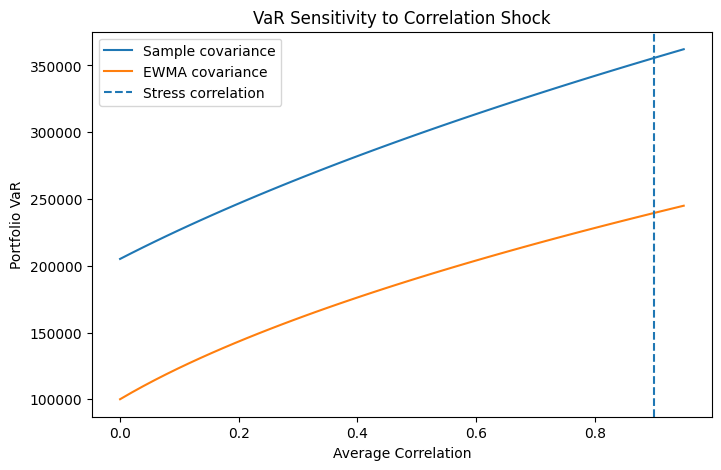

In [15]:
# More analysis
corr_grid = np.linspace(0, 0.95, 50)

sample_vars = []
ewma_vars = []

sample_cov = returns.cov().to_numpy()
ewma_cov = ewma_covariance(returns)

for c in corr_grid:

    sample_stress = increase_correlation(sample_cov, c)
    ewma_stress = increase_correlation(ewma_cov, c)

    sample_var = parametric_var_from_cov(sample_stress, portfolio, alpha)
    ewma_var = parametric_var_from_cov(ewma_stress, portfolio, alpha)

    sample_vars.append(sample_var)
    ewma_vars.append(ewma_var)

plt.figure(figsize=(8,5))

plt.plot(corr_grid, sample_vars, label="Sample covariance")
plt.plot(corr_grid, ewma_vars, label="EWMA covariance")

plt.axvline(target_corr, linestyle="--", label="Stress correlation")

plt.xlabel("Average Correlation")
plt.ylabel("Portfolio VaR")
plt.title("VaR Sensitivity to Correlation Shock")
plt.legend()

# Save Plot
plt.savefig(fig_dir / "var_sensitivity_to_correlation.png", dpi=300)

plt.show()

The EWMA VaR curve lies below the sample-covariance VaR curve because recent estimated volatility is lower, but both increase as correlations rise. The larger EWMA stress uplift comes mainly from its lower baseline VaR, so the same absolute deterioration in diversification translates into a larger percentage increase.